In [1]:
import os
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
TEST_DIR = "./brain_tumor/Dataset/classification_data/Processed/test"

IMAGE_SIZE = 224

BATCH_SIZE = 16

MODEL_PATH = "./checkpoints/best_model.pth"

device = torch.device("cpu")

In [3]:
class BrainTumourDataset(Dataset):

    def __init__(self, root_dir, image_size=224):

        self.root_dir = root_dir
        self.image_size = image_size

        self.classes = sorted(
            [
                folder
                for folder in os.listdir(root_dir)
                if os.path.isdir(
                    os.path.join(root_dir, folder)
                )
            ]
        )

        self.class_to_idx = {
            cls: idx
            for idx, cls in enumerate(
                self.classes
            )
        }

        self.samples = []

        for cls_name in self.classes:

            cls_dir = os.path.join(
                root_dir,
                cls_name
            )

            for img_name in os.listdir(cls_dir):

                if img_name.lower().endswith(
                    (
                        ".png",
                        ".jpg",
                        ".jpeg"
                    )
                ):

                    self.samples.append(
                        (
                            os.path.join(
                                cls_dir,
                                img_name
                            ),
                            self.class_to_idx[
                                cls_name
                            ]
                        )
                    )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        img_path, label = self.samples[idx]

        image = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        image = cv2.resize(
            image,
            (
                self.image_size,
                self.image_size
            )
        )

        image = image.astype(
            np.float32
        ) / 255.0

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, label

In [4]:
test_dataset = BrainTumourDataset(
    TEST_DIR,
    IMAGE_SIZE
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "Test Samples:",
    len(test_dataset)
)

print(
    test_dataset.classes
)

Test Samples: 2208
['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
class BrainTumourCNN(nn.Module):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                128,
                256,
                3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [7]:
model = BrainTumourCNN(
    num_classes=len(
        test_dataset.classes
    )
)
checkpoint = torch.load(
    "checkpoints/best_model.pth",
    map_location=device
)


model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)

model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [8]:
criterion = nn.CrossEntropyLoss()

test_loss = 0

all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in tqdm(
        test_loader,
        desc="Testing"
    ):

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        test_loss += loss.item()

        preds = outputs.argmax(
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

test_loss /= len(test_loader)

print(
    f"Test Loss: {test_loss:.4f}"
)

Testing: 100%|██████████| 138/138 [02:28<00:00,  1.08s/it]

Test Loss: 0.7369


In [10]:
accuracy = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_preds,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted"
)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1 Score : {f1:.4f}"
)

Accuracy : 0.7568
Precision: 0.7766
Recall   : 0.7568
F1 Score : 0.7490


In [11]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=
        test_dataset.classes
    )
)

              precision    recall  f1-score   support

      glioma       0.93      0.58      0.72       683
  meningioma       0.63      0.61      0.62       541
     notumor       0.74      0.94      0.83       400
   pituitary       0.76      0.97      0.85       584

    accuracy                           0.76      2208
   macro avg       0.76      0.78      0.75      2208
weighted avg       0.78      0.76      0.75      2208



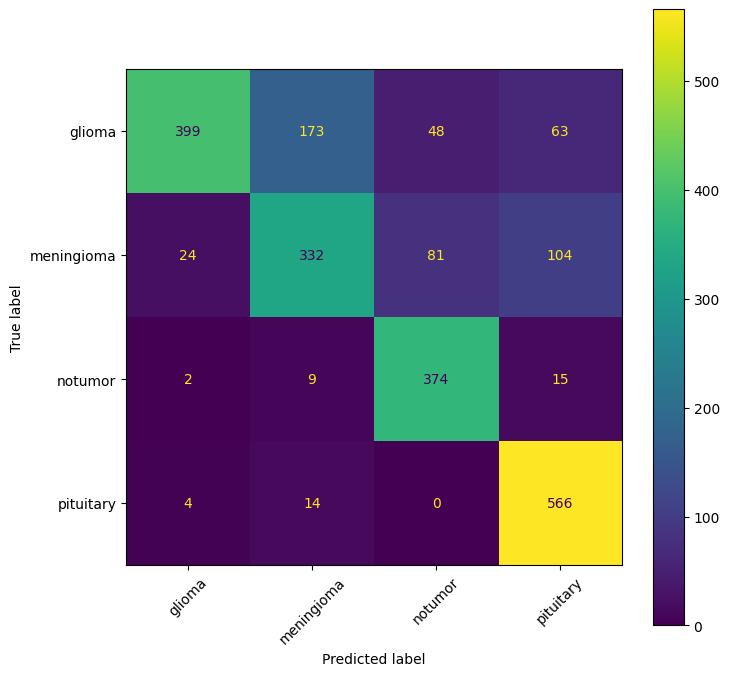

In [12]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=
    test_dataset.classes
)

fig, ax = plt.subplots(
    figsize=(8,8)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.show()